In [1]:
from astropy.coordinates import SkyCoord

RetII = SkyCoord("03h35m47.83s", "−54d02m47.80s")

In [4]:
RetII.dec.deg

np.float64(-54.04661111111111)

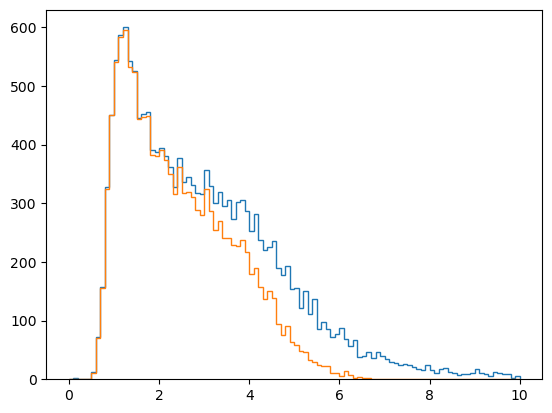

In [27]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np

RetIIPM = Table.read(
    "/home/vwetzell/Documents/Processed_RETII_v1/RetII_v0.0/RetIIPM_GAIA_PSF_MAG_APER_8_EXTMASH.fits"
)
# RetIIPM = Table.read('/media/vwetzell/SeaStick/210524_Backup/Documents/RetIIPM/RetIIPM_PSF_APER_8_STARS.fits')

RetIIPM = RetIIPM[RetIIPM["pm_1"] < 20]

# gaia_stars = ~np.isnan(RetIIPM["pm_2"])

RetIIPM["pm"] = RetIIPM["pm_1"]
# RetIIPM["pm"][gaia_stars] = RetIIPM["pm_2"][gaia_stars]

RetIIPM["pmra"] = RetIIPM["pmra_1"]
# RetIIPM["pmra"][gaia_stars] = RetIIPM["pmra_2"][gaia_stars]

RetIIPM["pmdec"] = RetIIPM["pmdec_1"]
# RetIIPM["pmdec"][gaia_stars] = RetIIPM["pmdec_2"][gaia_stars]

RetIIPM["ra"] = RetIIPM["ra_1"]
# RetIIPM["ra"][gaia_stars] = RetIIPM["ra_2"][gaia_stars]

RetIIPM["dec"] = RetIIPM["dec_1"]
# RetIIPM["dec"][gaia_stars] = RetIIPM["dec_2"][gaia_stars]

# RetIIPM["c_xx"] = RetIIPM["c_xx"]
# RetIIPM["c_xx"][gaia_stars] = ((RetIIPM["ra_error"] / 1000) ** 2)[gaia_stars]

# RetIIPM["c_yy"] = RetIIPM["c_yy"]
# RetIIPM["c_yy"][gaia_stars] = ((RetIIPM["dec_error"] / 1000) ** 2)[gaia_stars]

# RetIIPM["c_xy"] = RetIIPM["c_xy"]
# RetIIPM["c_xy"][gaia_stars] = (
#     (RetIIPM["ra_error"] / 1000)
#     * (RetIIPM["dec_error"] / 1000)
#     * RetIIPM["ra_dec_corr"]
# )[gaia_stars]

# RetIIPM["c_vxvx"] = RetIIPM["c_vxvx"]
# RetIIPM["c_vxvx"][gaia_stars] = ((RetIIPM["pmra_error"] / 1000) ** 2)[gaia_stars]

# RetIIPM["c_vyvy"] = RetIIPM["c_vyvy"]
# RetIIPM["c_vyvy"][gaia_stars] = ((RetIIPM["pmdec_error"] / 1000) ** 2)[gaia_stars]

# RetIIPM["c_vxvy"] = RetIIPM["c_vxvy"]
# RetIIPM["c_vxvy"][gaia_stars] = (
#     (RetIIPM["pmra_error"] / 1000)
#     * (RetIIPM["pmdec_error"] / 1000)
#     * RetIIPM["pmra_pmdec_corr"]
# )[gaia_stars]


# RetIIPM = RetIIPM[RetIIPM["EXT_MASH"] == 0]


plt.figure()
# plt.yscale("log")
plt.hist(
    RetIIPM["chisqTotal"] / RetIIPM["dof"], histtype="step", bins=100, range=(0, 10)
)
RetIIPM = RetIIPM[(RetIIPM["dof"] > 25)]
plt.hist(
    RetIIPM["chisqTotal"] / RetIIPM["dof"], histtype="step", bins=100, range=(0, 10)
)
# RetIIPM = RetIIPM[RetIIPM['dof']>50]
# plt.hist(RetIIPM['chisqTotal']/RetIIPM['dof'],histtype='step',bins=100,range=(0,10))
plt.show()

In [28]:
# plt.figure()
# plt.hist(np.sqrt(RetIIPM["c_xx"]), histtype="step", bins=100)
# plt.hist(np.sqrt(RetIIPM_mixed["c_xx"]), histtype="step", bins=100)
# plt.show()

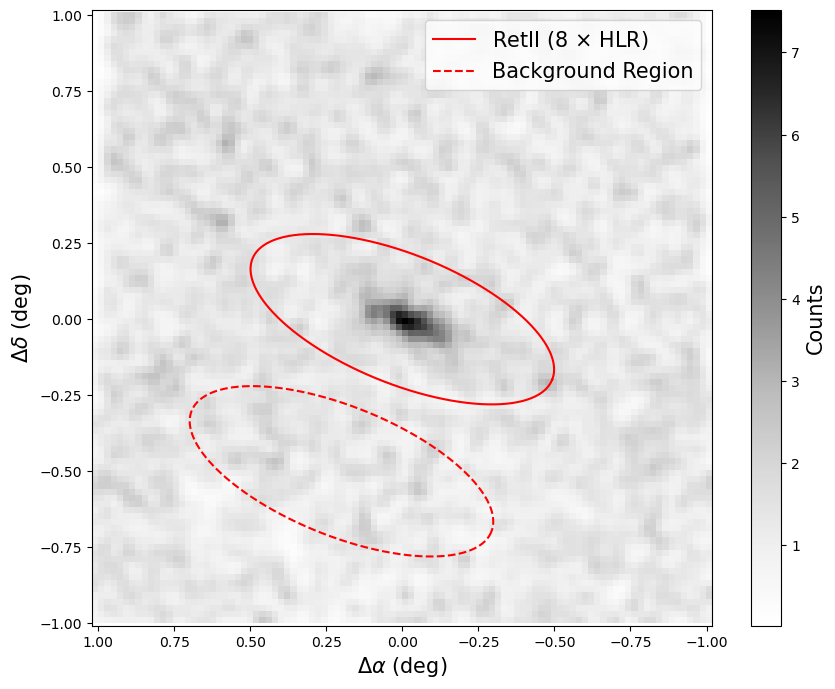

In [29]:
from scipy.ndimage import gaussian_filter
import numpy as np

eps = 0.6
hlr = 6.3 / 60 * np.sqrt(1 - eps)
theta = 68 * np.pi / 180

n_hlr = 8

z = np.linspace(0, 2 * np.pi, 1000)

x = n_hlr * hlr * np.array([np.cos(z), np.sin(z) * (1 - eps)]).T

ra_hlr, dec_hlr = np.einsum(
    "...ij,...i",
    np.array(
        [
            [np.cos(theta + np.pi / 2), -np.sin(theta + np.pi / 2)],
            [np.sin(theta + np.pi / 2), np.cos(theta + np.pi / 2)],
        ]
    )[np.newaxis, :, :],
    x,
).T

offra_hlr, offdec_hlr = np.einsum(
    "...ij,...i",
    np.array(
        [
            [np.cos(theta + np.pi / 2), -np.sin(theta + np.pi / 2)],
            [np.sin(theta + np.pi / 2), np.cos(theta + np.pi / 2)],
        ]
    )[np.newaxis, :, :],
    x[np.newaxis, :],
).T

RetIIPM["dAlpha"] = (RetIIPM["ra"] - RetII.ra.value) * np.cos(
    (np.pi / 180) * RetII.dec.value
)
RetIIPM["dDelta"] = RetIIPM["dec"] - RetII.dec.value

RetIIpos, xedges, yedges = np.histogram2d(
    RetIIPM["dAlpha"], RetIIPM["dDelta"], bins=100
)


plt.figure(figsize=(10, 8))
plt.axis("equal")
plt.imshow(
    gaussian_filter(RetIIpos, sigma=1).T,
    origin="lower",
    cmap="Greys",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
)

plt.plot(ra_hlr, dec_hlr, c="r", label=r"RetII (8 $\times$ HLR)")
plt.plot(offra_hlr + 0.2, offdec_hlr - 0.5, c="r", ls="--", label="Background Region")
plt.gca().invert_xaxis()
plt.xlabel(r"$\Delta\alpha$ (deg)", fontsize=15)
plt.ylabel(r"$\Delta\delta$ (deg)", fontsize=15)
plt.colorbar().set_label(r"Counts", fontsize=15)
plt.legend(fontsize=15)
plt.show()

In [30]:
onRetIIPM = RetIIPM[
    (
        RetIIPM["dAlpha"] * np.cos(theta + np.pi / 2)
        - RetIIPM["dDelta"] * np.sin(theta + np.pi / 2)
    )
    ** 2
    + (
        RetIIPM["dAlpha"] * np.sin(theta + np.pi / 2)
        + RetIIPM["dDelta"] * np.cos(theta + np.pi / 2)
    )
    ** 2
    / (1 - eps) ** 2
    < (n_hlr * hlr) ** 2
]

offRetIIPM = RetIIPM[
    (
        ((RetIIPM["dAlpha"] + 0.2) * np.cos(theta)) * np.cos(theta + np.pi / 2)
        - ((RetIIPM["dDelta"] - 0.5) * np.sin(theta)) * np.sin(theta + np.pi / 2)
    )
    ** 2
    + (
        ((RetIIPM["dAlpha"] + 0.2) * np.cos(theta)) * np.sin(theta + np.pi / 2)
        + ((RetIIPM["dDelta"] - 0.5) * np.sin(theta)) * np.cos(theta + np.pi / 2)
    )
    ** 2
    / (1 - eps) ** 2
    < (n_hlr * hlr) ** 2
]

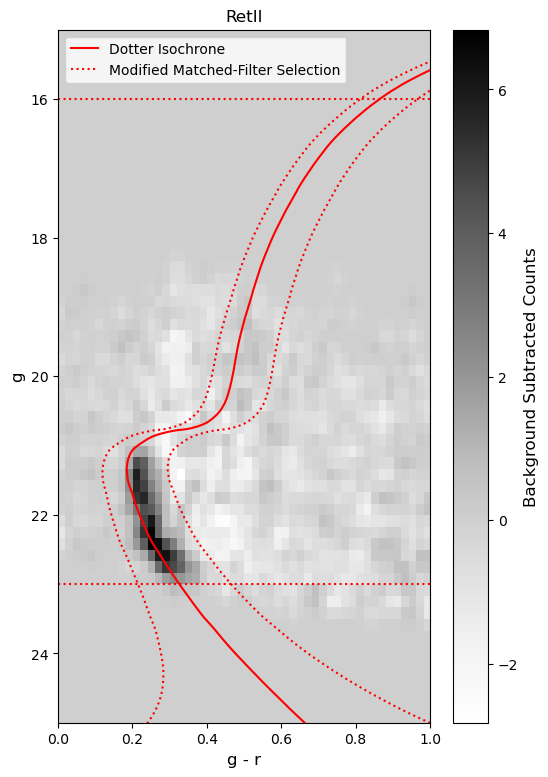

In [31]:
from ugali import isochrone

E = 2.0
delmu = 0.5
c1 = 0.05
c2 = 0.1


def err(mag_g):
    return 0.001 + np.exp((mag_g - 27.09) / 1.09)


feh = -2.4

mu = 5 * np.log10(31.4 * 1000) - 5

iso = isochrone.factory(
    name="Dotter2008", age=13.5, distance_modulus=mu, metallicity=10**feh
)


RetIIHess, xedgesHess, yedgesHess = np.histogram2d(
    onRetIIPM["PSF_MAG_APER_8_G"] - onRetIIPM["PSF_MAG_APER_8_R"],
    onRetIIPM["PSF_MAG_APER_8_G"],
    range=((0, 1), (14, 26)),
    bins=(50, 72),
)

notRetIIHess, xedges, yedges = np.histogram2d(
    offRetIIPM["PSF_MAG_APER_8_G"] - offRetIIPM["PSF_MAG_APER_8_R"],
    offRetIIPM["PSF_MAG_APER_8_G"],
    range=((0, 1), (14, 26)),
    bins=(50, 72),
)


plt.figure(figsize=(6, 9))
plt.title("RetII")

plt.imshow(
    gaussian_filter(RetIIHess - notRetIIHess, sigma=0.7).T,
    origin="lower",
    cmap="Greys",
    aspect="auto",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
)

plt.colorbar().set_label(r"Background Subtracted Counts", fontsize=12)
plt.plot(
    0.0 + iso.mag_1[:350] - iso.mag_2[:350],
    iso.mag_1[:350] + iso.distance_modulus,
    c="r",
    label="Dotter Isochrone",
)

plt.plot(
    0.0
    + iso.mag_1[:350]
    - iso.mag_2[:350]
    - (E * err(iso.mag_1[:350] + iso.distance_modulus + delmu / 2))
    - c1,
    iso.mag_1[:350] + iso.distance_modulus,
    c="r",
    ls=":",
    label="Modified Matched-Filter Selection",
)

plt.plot(
    0.0
    + iso.mag_1[:350]
    - iso.mag_2[:350]
    + (E * err(iso.mag_1[:350] + iso.distance_modulus - delmu / 2))
    + c2,
    iso.mag_1[:350] + iso.distance_modulus,
    c="r",
    ls=":",
)

plt.axhline(16, c="r", ls=":")
plt.axhline(23, c="r", ls=":")


plt.ylim(15, 25)
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.xlabel("g - r", fontsize=12)
plt.ylabel("g", fontsize=12)
plt.legend(loc=2)
plt.show()

In [32]:
g_lo = 16
g_hi = 23

mag_cut = (RetIIPM["PSF_MAG_APER_8_G"] < g_hi) & (RetIIPM["PSF_MAG_APER_8_G"] > g_lo)

# tbl_g_cut = RetIIPM[(RetIIPM['PSF_MAG_APER_8_G']<g_hi)&(RetIIPM['PSF_MAG_APER_8_G']>g_lo)]

# RetIIPM_g_cut = tbl_g_cut

color_ids = [
    i
    for i in range(len(RetIIPM))
    if (RetIIPM["PSF_MAG_APER_8_G"][i] - RetIIPM["PSF_MAG_APER_8_R"][i])
    > (
        0.0
        + iso.mag_1[
            np.argmin(
                np.abs(
                    RetIIPM["PSF_MAG_APER_8_G"][i] - iso.mag_1 - iso.distance_modulus
                )
            )
        ]
        - iso.mag_2[
            np.argmin(
                np.abs(
                    RetIIPM["PSF_MAG_APER_8_G"][i] - iso.mag_1 - iso.distance_modulus
                )
            )
        ]
        - (
            E
            * err(
                iso.mag_1[
                    np.argmin(
                        np.abs(
                            RetIIPM["PSF_MAG_APER_8_G"][i]
                            - iso.mag_1
                            - iso.distance_modulus
                        )
                    )
                ]
                + iso.distance_modulus
                + delmu / 2
            )
        )
        - c1
    )
    and (RetIIPM["PSF_MAG_APER_8_G"][i] - RetIIPM["PSF_MAG_APER_8_R"][i])
    < (
        0.0
        + iso.mag_1[
            np.argmin(
                np.abs(
                    RetIIPM["PSF_MAG_APER_8_G"][i] - iso.mag_1 - iso.distance_modulus
                )
            )
        ]
        - iso.mag_2[
            np.argmin(
                np.abs(
                    RetIIPM["PSF_MAG_APER_8_G"][i] - iso.mag_1 - iso.distance_modulus
                )
            )
        ]
        + (
            E
            * err(
                iso.mag_1[
                    np.argmin(
                        np.abs(
                            RetIIPM["PSF_MAG_APER_8_G"][i]
                            - iso.mag_1
                            - iso.distance_modulus
                        )
                    )
                ]
                + iso.distance_modulus
                - delmu / 2
            )
        )
        + c2
    )
]


color_cut = np.zeros_like(mag_cut, dtype=bool)
color_cut[color_ids] = True

RetIIPM_gr_cut = RetIIPM[mag_cut & color_cut]

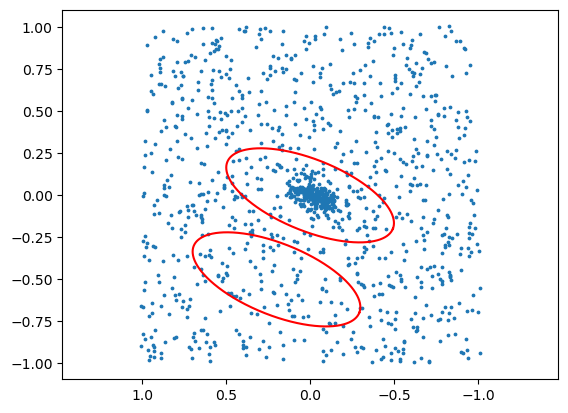

In [33]:
onRetIIPM_gr_cut = RetIIPM_gr_cut[
    (
        RetIIPM_gr_cut["dAlpha"] * np.cos(theta + np.pi / 2)
        - RetIIPM_gr_cut["dDelta"] * np.sin(theta + np.pi / 2)
    )
    ** 2
    + (
        RetIIPM_gr_cut["dAlpha"] * np.sin(theta + np.pi / 2)
        + RetIIPM_gr_cut["dDelta"] * np.cos(theta + np.pi / 2)
    )
    ** 2
    / (1 - eps) ** 2
    < (n_hlr * hlr) ** 2
]

offRetIIPM_gr_cut = RetIIPM_gr_cut[
    (
        (RetIIPM_gr_cut["dAlpha"] - 0.2) * np.cos(theta + np.pi / 2)
        - (RetIIPM_gr_cut["dDelta"] + 0.5) * np.sin(theta + np.pi / 2)
    )
    ** 2
    + (
        (RetIIPM_gr_cut["dAlpha"] - 0.2) * np.sin(theta + np.pi / 2)
        + (RetIIPM_gr_cut["dDelta"] + 0.5) * np.cos(theta + np.pi / 2)
    )
    ** 2
    / (1 - eps) ** 2
    < (n_hlr * hlr) ** 2
]


plt.figure()
plt.axis("equal")
plt.scatter(RetIIPM_gr_cut["dAlpha"], RetIIPM_gr_cut["dDelta"], s=3)
plt.plot(ra_hlr, dec_hlr, c="r")
plt.plot(offra_hlr + 0.2, offdec_hlr - 0.5, c="r")
plt.gca().invert_xaxis()
plt.show()

In [34]:
len(RetIIPM_gr_cut)

1229

In [ ]:
import pymc as pm
import jax
import jax.numpy as jnp

with pm.Model() as model:

    RetII_data = pm.Data(
        "RetII_data",
        jax.device_put(
            jnp.array(
                [
                    3600 * RetIIPM_gr_cut["dAlpha"],
                    3600 * RetIIPM_gr_cut["dDelta"],
                    RetIIPM_gr_cut["pmra"] / 1000,
                    RetIIPM_gr_cut["pmdec"] / 1000,
                ]
            ).T,
        ),
    )

    RetII_pos_cov = pm.Data(
        "RetII_pos_cov",
        jnp.array(
            [
                [
                    RetIIPM_gr_cut["c_xx"],
                    RetIIPM_gr_cut["c_xy"],
                ],
                [
                    RetIIPM_gr_cut["c_xy"],
                    RetIIPM_gr_cut["c_yy"],
                ],
            ]
        ).T,
    )

    RetII_pm_cov = pm.Data(
        "RetII_pm_cov",
        jnp.array(
            [
                [
                    RetIIPM_gr_cut["c_vxvx"],
                    RetIIPM_gr_cut["c_vxvy"],
                ],
                [
                    RetIIPM_gr_cut["c_vxvy"],
                    RetIIPM_gr_cut["c_vyvy"],
                ],
            ]
        ).T,
    )

    # x_min = pm.Data("x_min", jax.device_put(jnp.min(3600 * RetIIPM_gr_cut["dAlpha"])))
    # x_max = pm.Data("x_max", jax.device_put(jnp.max(3600 * RetIIPM_gr_cut["dAlpha"])))
    # y_min = pm.Data("y_min", jax.device_put(jnp.min(3600 * RetIIPM_gr_cut["dDelta"])))
    # y_max = pm.Data("y_max", jax.device_put(jnp.max(3600 * RetIIPM_gr_cut["dDelta"])))

    x_min = pm.math.min(3600 * RetII_data[:, 0])
    x_max = pm.math.max(3600 * RetII_data[:, 0])
    y_min = pm.math.min(3600 * RetII_data[:, 1])
    y_max = pm.math.max(3600 * RetII_data[:, 1])
    area = (x_max - x_min) * (y_max - y_min)

    # Global mixture weight: fraction of stars from the dwarf galaxy.
    # p_mix = pm.Beta("p_mix", alpha=1.0, beta=1.0)
    p_mix = pm.Beta("p_mix", mu=0.25, sigma=0.15)

    # ===== Dwarf Galaxy Component =====
    # -- Spatial (Plummer Profile) --
    # Priors for the Plummer parameters:
    x0 = pm.Normal(
        "x0",
        mu=0,
        sigma=120,
    )  # Center of the Plummer profile
    y0 = pm.Normal(
        "y0",
        mu=0,
        sigma=120,
    )  # Center of the Plummer profile
    a = pm.TruncatedNormal(
        "a", mu=6.3, sigma=2.0, lower=2, upper=10.6
    )  # Plummer scale radius
    a_arcsec = a * 60  # Convert to degrees
    eps = pm.TruncatedNormal(
        "eps", mu=0.6, sigma=0.1, lower=0.3, upper=0.9
    )  # Ellipticity of the Plummer profile

    # x0 = 0
    # y0 = 0
    # a = 6.3
    # a_arcsec = a * 60  # Convert to arcseconds
    # eps = 0.6  # Ellipticity of the Plummer profile
    theta = pm.TruncatedNormal(
        "theta",
        mu=68,
        sigma=15,
        lower=0,
        upper=180,
    )  # Orientation of the Plummer profile

    theta_rad = (90 - theta) * jnp.pi / 180

    # Define a custom log-probability for the Plummer profile.
    def plummer_logp(pos, cov, x0, y0, a, eps, theta):

        N = pos.shape[0]
        # Shift the positions according to the center (x0, y0).
        new_pos = pm.math.stack([pos[:, 0] - x0, pos[:, 1] - y0]).T

        # Rotate the positions and covariances according to the angle theta.
        cos_theta = pm.math.cos(theta)
        sin_theta = pm.math.sin(theta)

        rot_matrix = pm.math.stack(
            [
                [cos_theta, -sin_theta],
                [sin_theta, cos_theta],
            ]
        )
        pos_rotated = pm.math.dot(new_pos, rot_matrix)

        cov_rotated = pm.math.dot(rot_matrix, pm.math.dot(cov, rot_matrix).T).T

        # Calculate the Plummer profile log-likelihood.
        r2 = (
            pm.math.sqr(pos_rotated[:, 0])
            + (pm.math.sqr(pos_rotated[:, 1]) / pm.math.sqr(1 - eps))
        ) / pm.math.sqr(a)
        r2_err = (
            cov_rotated[:, 0, 0] + (cov_rotated[:, 1, 1] / pm.math.sqr(1 - eps))
        ) / pm.math.sqr(a)

        r2_eff = r2 + r2_err

        logp = (
            -pm.math.log(jnp.pi)
            - 2 * pm.math.log(a)
            - pm.math.log(1 - eps)
            - 2 * pm.math.log(1 + r2_eff)
        )

        return logp

    # Compute the Plummer log-likelihood for each star's position.
    logp_plum = plummer_logp(
        RetII_data[:, :2], RetII_pos_cov, x0, y0, a_arcsec, eps, theta_rad
    )

    # -- Proper Motions for the Dwarf Galaxy --
    # We still model proper motions as a 2D Gaussian.
    mu_gal_pm = pm.Normal("mu_gal_pm", mu=[2.36, -1.32], sigma=1.0, shape=2)
    mu_gal_pm_arcsec =  mu_gal_pm / 1000
    # For the proper motion covariance, we use an LKJ prior.
    packed_chol_gal_pm = pm.LKJCholeskyCov(
        "packed_chol_gal_pm",
        n=2,
        eta=2,
        sd_dist=pm.Exponential.dist(scale=0.005),
        compute_corr=False,
        store_in_trace=False,
    )
    chol_gal_pm = pm.expand_packed_triangular(2, packed_chol_gal_pm)
    Sigma_gal_pm = pm.math.dot(chol_gal_pm, chol_gal_pm.T)
    sigma_gal_pmra = pm.Deterministic(
        "sigma_gal_pmra", pm.math.sqrt(Sigma_gal_pm[0, 0]) * 1000
    )
    sigma_gal_pmdec = pm.Deterministic(
        "sigma_gal_pmdec", pm.math.sqrt(Sigma_gal_pm[1, 1]) * 1000
    )
    # Incorporate the measurement error on proper motions.
    # Here we extract the proper motion sub-block from the measurement error.
    cov_err_pm = RetII_pm_cov  # shape (N,2,2)
    Sigma_gal_pm_eff = Sigma_gal_pm + cov_err_pm
    logp_gal_pm = pm.logp(
        pm.MvNormal.dist(mu=mu_gal_pm_arcsec, cov=Sigma_gal_pm_eff), RetII_data[:, 2:]
    )

    # Total log-likelihood for the dwarf galaxy component is the sum of the spatial and proper motion parts.
    logp_gal = logp_plum + logp_gal_pm

    # ===== Field Stars Component Intrinsic Distribution =====
    mu_field_pm = pm.Normal("mu_field_pm", mu=0, sigma=5, shape=2)
    mu_field_pm_arcsec =  mu_field_pm 
    packed_chol_field = pm.LKJCholeskyCov(
        "packed_chol_field_pm",
        n=2,
        eta=2,
        sd_dist=pm.Exponential.dist(scale=0.01),
        compute_corr=False,
        store_in_trace=False,
    )
    chol_field = pm.expand_packed_triangular(2, packed_chol_field)
    Sigma_field_pm = pm.math.dot(chol_field, chol_field.T)
    Sigma_field_pm_eff = Sigma_field_pm + RetII_pm_cov
    sigma_field_pmra = pm.Deterministic(
        "sigma_field_pmra", pm.math.sqrt(Sigma_field_pm[0, 0]) * 1000
    )
    sigma_field_pmdec = pm.Deterministic(
        "sigma_field_pmdec", pm.math.sqrt(Sigma_field_pm[1, 1]) * 1000
    )

    # Uniform position log-probability
    def uniform_logp(values):
        in_box = (
            (values[:, 0] >= x_min)
            & (values[:, 0] <= x_max)
            & (values[:, 1] >= y_min)
            & (values[:, 1] <= y_max)
        )
        return pm.math.switch(in_box, -pm.math.log(area), -jnp.inf)

    logp_field_pos = uniform_logp(RetII_data[:, :2])

    logp_field_pm = pm.logp(
        pm.MvNormal.dist(mu_field_pm_arcsec, Sigma_field_pm_eff), RetII_data[:, 2:]
    )

    logp_field = logp_field_pos + logp_field_pm

    # ===== Mixture Likelihood =====
    logp_mix = pm.math.logaddexp(
        pm.math.log(p_mix) + logp_gal, pm.math.log(1 - p_mix) + logp_field
    )

    pm.Potential("likelihood", pm.math.sum(logp_mix))

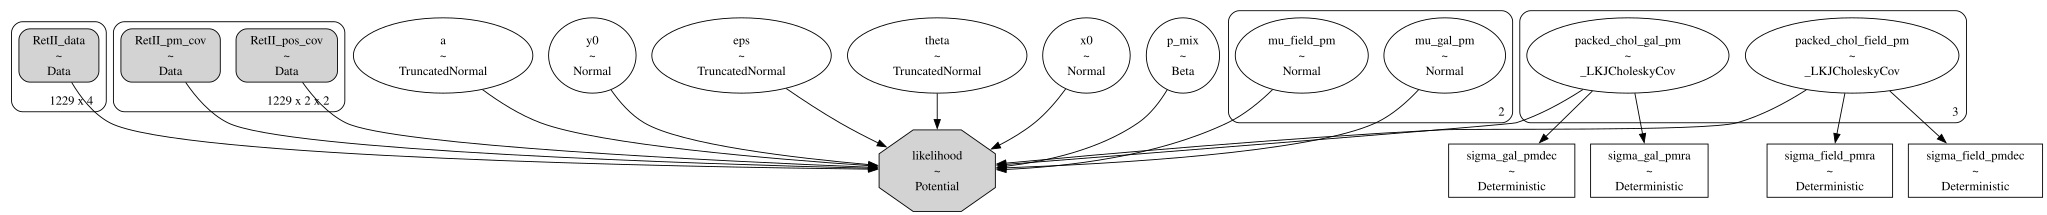

In [48]:
pm.model_to_graphviz(model)

In [49]:
from pymc.model.transform.optimization import freeze_dims_and_data

frozen_model = freeze_dims_and_data(model)


In [50]:
# pt.unique(x).mean() has to be computed in every logp function evaluation
print("Logp eval time (1000x): ", model.profile(model.logp()).fct_call_time)

# pt.uniqe(x).mean() is cached in the logp function
frozen_model = freeze_dims_and_data(model)
print("Logp eval time (1000x): ", frozen_model.profile(frozen_model.logp()).fct_call_time)

Logp eval time (1000x):  34.09348581545055
Logp eval time (1000x):  33.92442137200851


In [51]:
with frozen_model:
    prior_sample = pm.sample_prior_predictive(
        samples=10000,
        var_names=[
            "x0",
            "y0",
            "a",
            "eps",
            "theta",
            "mu_gal_pm",
            "p_mix",
            "packed_chol_gal_pm",
            "mu_field_pm",
            "packed_chol_field_pm",
        ],
    )

/tmp/ipykernel_3140946/3722966528.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior_sample = pm.sample_prior_predictive(
Sampling: [a, eps, mu_field_pm, mu_gal_pm, p_mix, packed_chol_field_pm, packed_chol_gal_pm, theta, x0, y0]


In [52]:
init_vals = {var: np.median(values,axis=(0,1)) for var, values in prior_sample["prior"].items() if "logp" not in var}
init_vals

{'a': np.float64(6.293486643328347),
 'eps': np.float64(0.5982977790481859),
 'mu_field_pm': array([-0.0258348 ,  0.02342637]),
 'mu_gal_pm': array([ 2.35629089, -1.31969695]),
 'p_mix': np.float64(0.22495960054068986),
 'packed_chol_field_pm': array([ 6.93392035e-03, -2.49683859e-07,  5.82672223e-03]),
 'packed_chol_gal_pm': array([ 3.57733652e-03, -2.04571216e-06,  2.95865989e-03]),
 'theta': np.float64(67.9605324218223),
 'x0': np.float64(-0.304886832435628),
 'y0': np.float64(-1.8565743981847662)}

In [53]:
with frozen_model:
    trace = pm.sample(
        10000,
        tune=2000,
        chains=4,
        # jitter_max_retries=100,
        nuts_sampler="numpyro",
        discard_tuned_samples=True,
        # progressbar=True,
        # initvals=init_vals,
        # step=pm.NUTS(
        #     target_accept=0.95,
        #     step_scale=0.25,
        #     k=0.75,
        #     t0=10,
        #     adapt_step_size=True,
        # ),
    )

/home/vwetzell/miniconda3/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 12000/12000 [20:42<00:00,  9.66it/s, 127 steps of size 3.97e-02. acc. prob=0.93] 


In [58]:
import arviz as az

az.summary(trace)

/home/vwetzell/miniconda3/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,6.375000e+00,0.393,5.656000e+00,7.131000e+00,0.002,0.002,32751.0,27760.0,1.0
a_arcsec,3.825020e+02,23.575,3.393380e+02,4.278860e+02,0.131,0.113,32751.0,27760.0,1.0
area,5.224980e+07,0.000,5.224980e+07,5.224980e+07,0.000,0.000,40000.0,40000.0,NaN
chol_field_pm[0],3.000000e-03,0.000,3.000000e-03,4.000000e-03,0.000,0.000,42712.0,30365.0,1.0
chol_field_pm[1],0.000000e+00,0.000,0.000000e+00,1.000000e-03,0.000,0.000,39163.0,28260.0,1.0
...,...,...,...,...,...,...,...,...,...
sigma_gal_pmra,1.000000e-03,0.000,1.000000e-03,1.000000e-03,0.000,0.000,43990.0,27811.0,1.0
theta,6.813600e+01,2.657,6.298400e+01,7.301500e+01,0.013,0.013,42032.0,29517.0,1.0
theta_rad,3.820000e-01,0.046,2.960000e-01,4.720000e-01,0.000,0.000,42032.0,29517.0,1.0
x0,-8.509600e+01,18.256,-1.184340e+02,-4.972600e+01,0.102,0.086,32076.0,29408.0,1.0


In [59]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> constant_data

In [ ]:
import arviz as az

az.to_json(trace,"./RetII_DES_GAIA.json")

'./RetII.json'

In [56]:
import arviz as az

trace = az.from_json("./RetII.json")

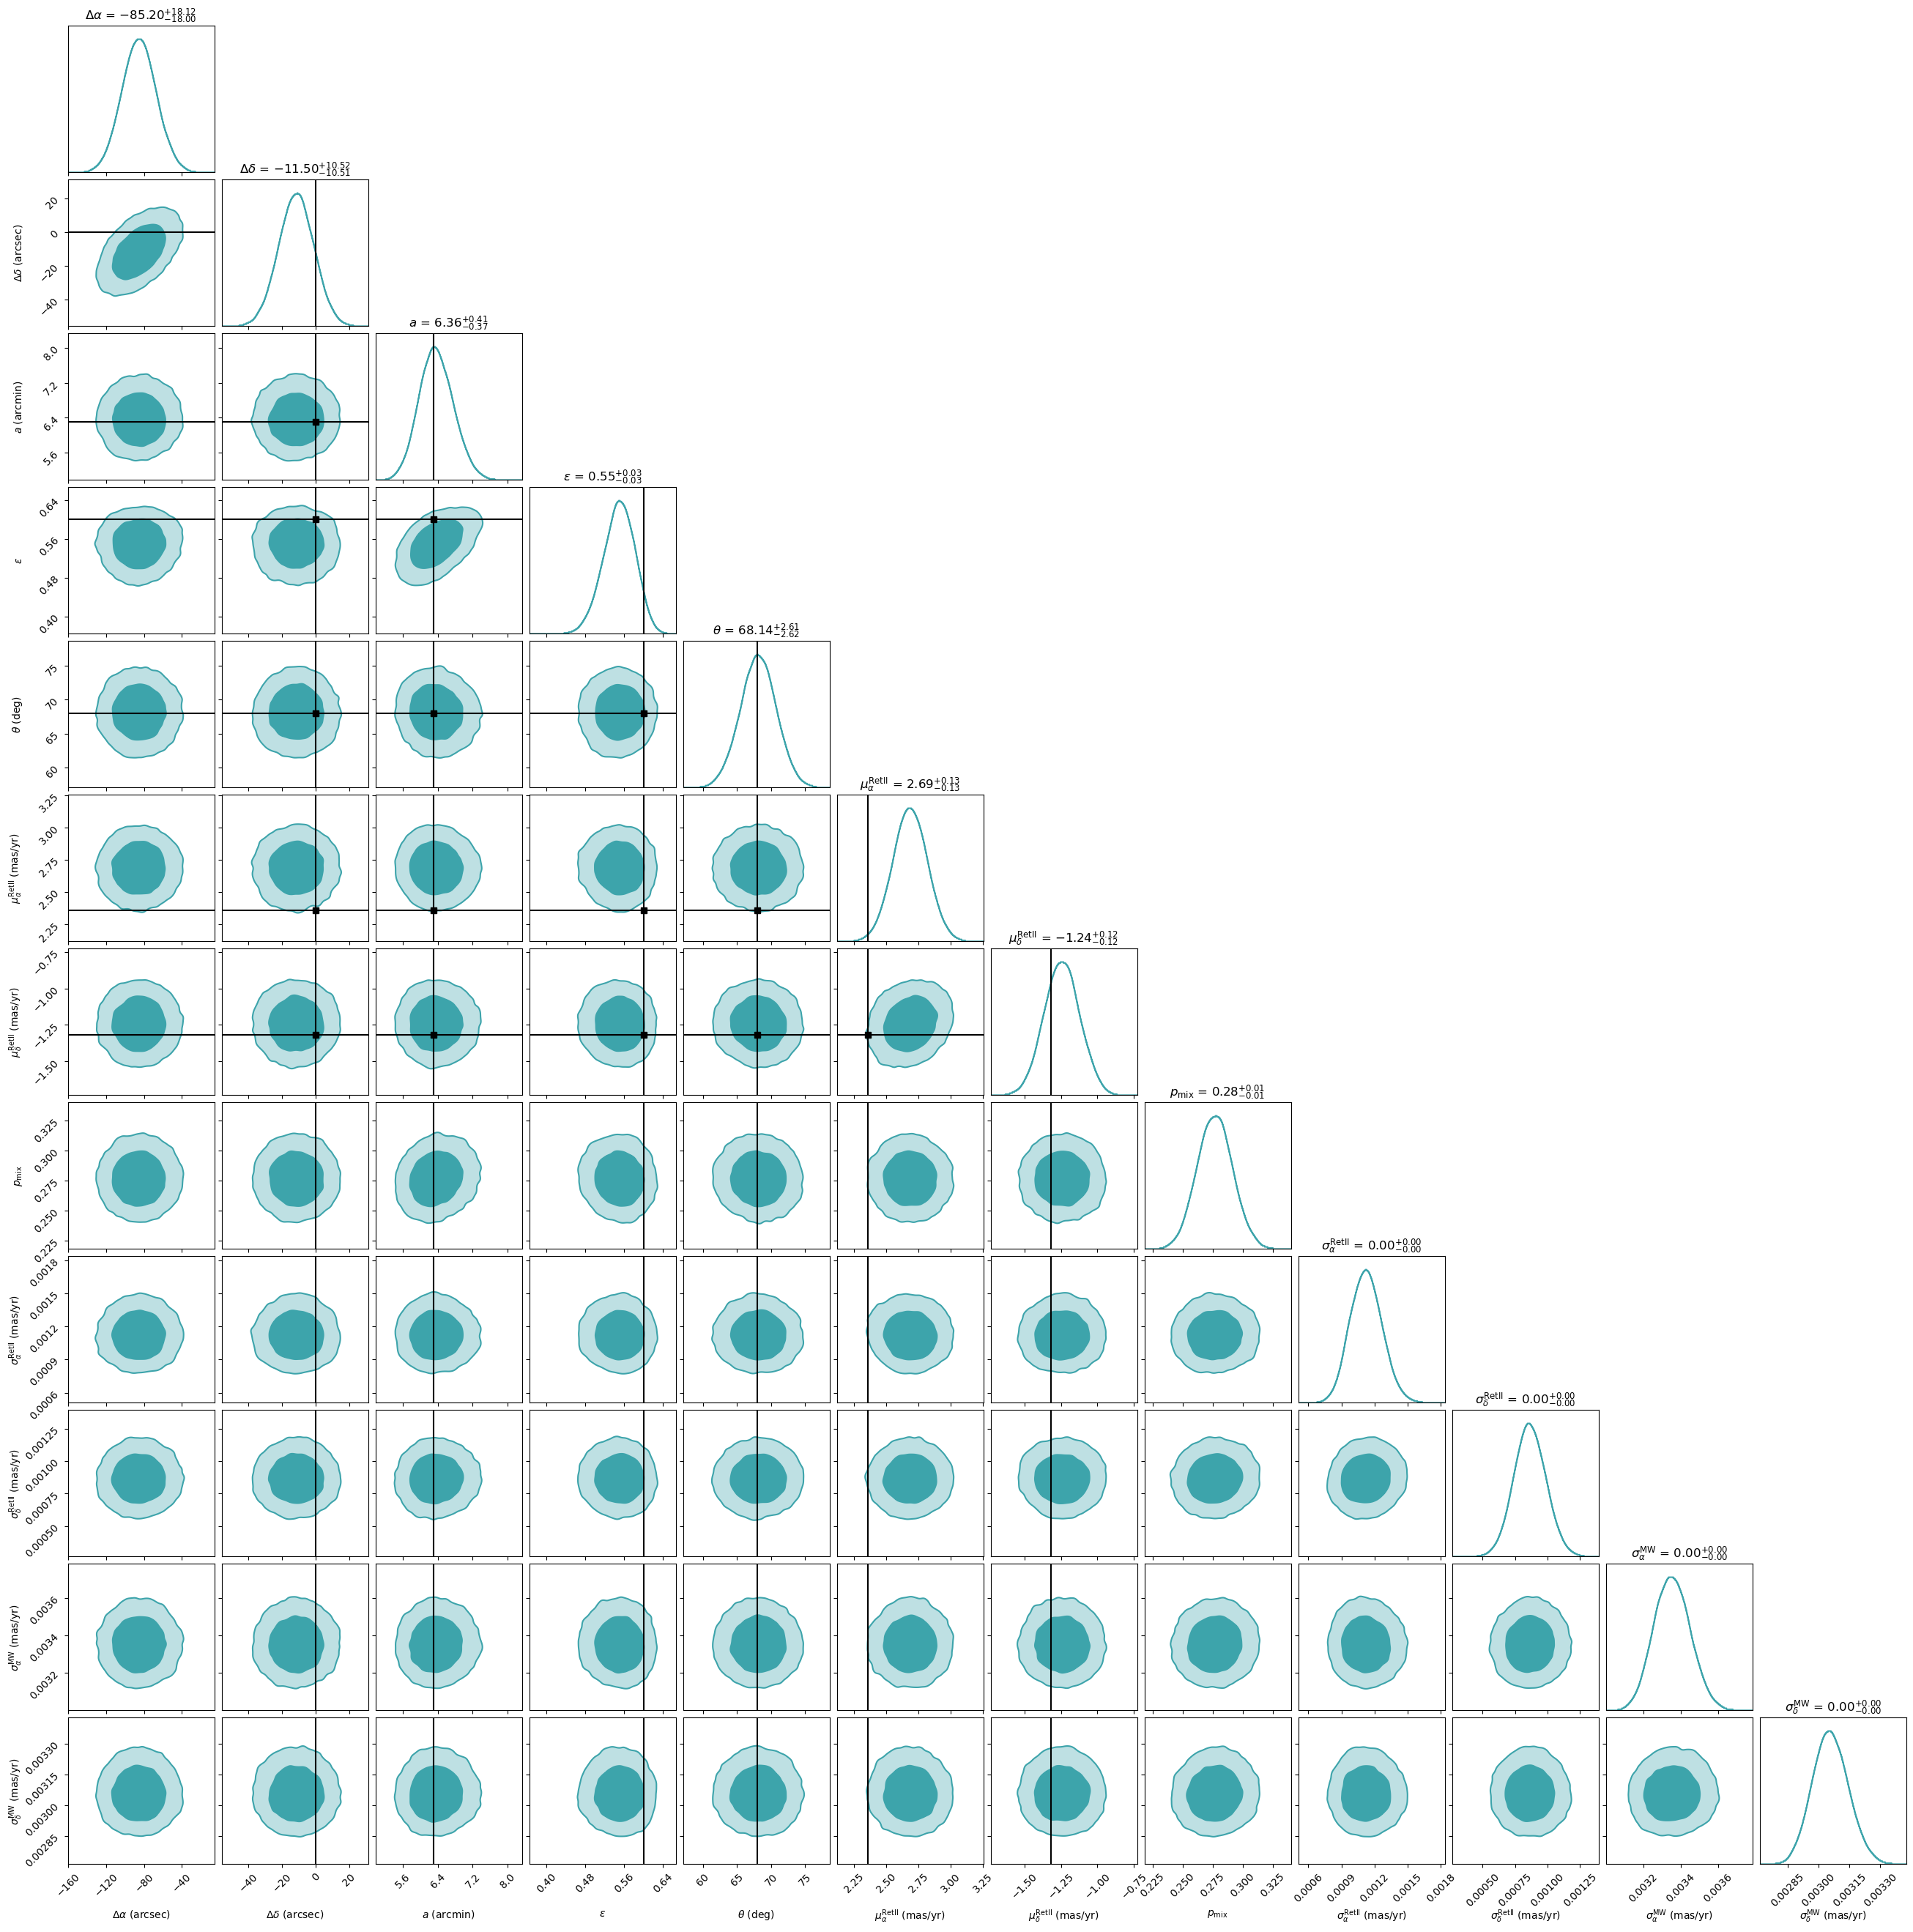

In [57]:
import corner

fig = corner.corner(
    trace,
    var_names=[
        "x0",
        "y0",
        "a",
        "eps",
        "theta",
        "mu_gal_pm",
        "p_mix",
        "sigma_gal_pmra",
        "sigma_gal_pmdec",
        "sigma_field_pmra",
        "sigma_field_pmdec",
    ],
    labels=[
        r"$\Delta\alpha$ (arcsec)",
        r"$\Delta\delta$ (arcsec)",
        r"$a$ (arcmin)",
        r"$\epsilon$",
        r"$\theta$ (deg)",
        r"$\mu_\alpha^\text{RetII}$ (mas/yr)",
        r"$\mu_\delta^\text{RetII}$ (mas/yr)",
        r"$p_\text{mix}$",
        r"$\sigma^\text{RetII}_{\alpha}$ (mas/yr)",
        r"$\sigma^\text{RetII}_{\delta}$ (mas/yr)",
        r"$\sigma^\text{MW}_{\alpha}$ (mas/yr)",
        r"$\sigma^\text{MW}_{\delta}$ (mas/yr)",
    ],
    # quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.2f',
    bins=1000,
    smooth=20,
    smooth1d=20,
    plot_datapoints=False,
    plot_density=False,
    levels=(0.68, 0.95),
    fill_contours=True,
    color="#3da4ab",
    truths=[
        0,
        0,
        6.3,
        0.6,
        68,
        2.36,
        -1.32,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
    ],
    truth_color="k",
)

import re
# Remove the parameter names from the titles
for ax in fig.axes:
    title = ax.get_title()
    new_title = re.sub(r"\s*\(.*?\)", "", ax.get_title())
    ax.set_title(new_title) 

plt.show()


# corner.corner(
#     trace_noturb,
#     var_names=[
#         "x0",
#         "y0",
#         "a",
#         "eps",
#         "theta",
#         "mu_gal_pm",
#         "p_mix",
#     ],
#     labels=[
#         r"$\Delta\alpha$ (arcsec)",
#         r"$\Delta\delta$ (arcsec)",
#         r"$a$ (arcmin)",
#         r"$\epsilon$",
#         r"$\theta$ (deg)",
#         r"$\mu_\alpha^\text{RetII}$ (mas/yr)",
#         r"$\mu_\delta^\text{RetII}$ (mas/yr)",
#         r"$p_\text{mix}$",
#     ],
#     # quantiles=[0.16, 0.5, 0.84],
#     # show_titles=True,
#     bins=1000,
#     smooth=20,
#     smooth1d=20,
#     plot_datapoints=False,
#     plot_density=False,
#     levels=(0.68, 0.95),
#     # fill_contours=True,
#     color="#fe8a71",
#     fig=fig,
# )
plt.show()

In [ ]:
# Assume we have posterior samples for the mixture probability (p_mix)
p_mix_samples = trace.posterior["p_mix"].values

# Extract log-likelihoods for each star
logp_gal_samples = trace.posterior["logp_gal"].values  # Shape (samples, N)
logp_field_samples = trace.posterior["logp_field"].values  # Shape (samples, N)

# Convert log-likelihoods to probabilities
p_gal_samples = np.exp(logp_gal_samples)
p_field_samples = np.exp(logp_field_samples)

# Compute membership probability using Bayes' theorem
membership_prob_samples = (p_mix_samples[:, :, None] * p_gal_samples) / (
    p_mix_samples[:, :, None] * p_gal_samples
    + (1 - p_mix_samples[:, :, None]) * p_field_samples
)

# Compute the mean membership probability across all posterior samples
membership_prob = membership_prob_samples.mean(axis=(0, 1))

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


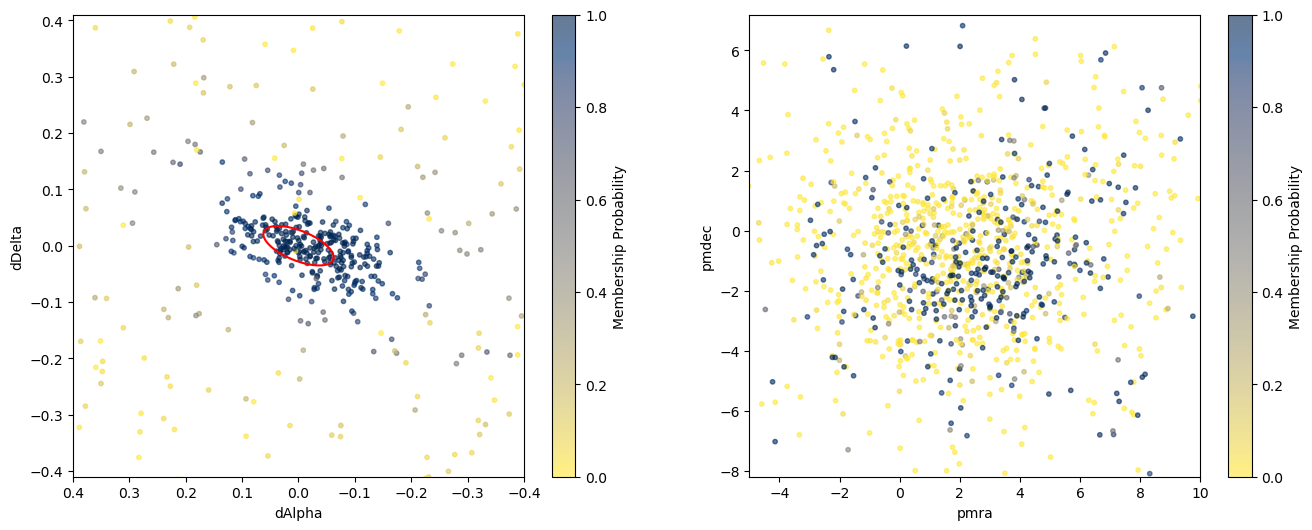

In [ ]:
eps = 0.6
hlr = 6.3 / 60 * np.sqrt(1 - eps)
theta = 68 * np.pi / 180

n_hlr = 1

z = np.linspace(0, 2 * np.pi, 1000)

x = n_hlr * hlr * np.array([np.cos(z), np.sin(z) * (1 - eps)]).T

ra_hlr, dec_hlr = np.einsum(
    "...ij,...i",
    np.array(
        [
            [np.cos(theta + np.pi / 2), -np.sin(theta + np.pi / 2)],
            [np.sin(theta + np.pi / 2), np.cos(theta + np.pi / 2)],
        ]
    )[np.newaxis, :, :],
    x,
).T

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
pcm = ax[0].scatter(
    RetIIPM_gr_cut["dAlpha"],
    RetIIPM_gr_cut["dDelta"],
    c=membership_prob,
    s=10,
    cmap="cividis_r",
    alpha=0.6,
    vmin=0,
    vmax=1,
)
ax[0].plot(ra_hlr, dec_hlr, c="r")
fig.colorbar(pcm, ax=ax[0], label="Membership Probability")
ax[0].set_xlabel("dAlpha")
ax[0].set_ylabel("dDelta")
ax[0].axis("equal")
ax[0].set_xlim(-0.4, 0.4)
ax[0].set_ylim(-0.4, 0.4)
ax[0].invert_xaxis()


pcm = ax[1].scatter(
    RetIIPM_gr_cut["pmra"],
    RetIIPM_gr_cut["pmdec"],
    c=membership_prob,
    s=10,
    cmap="cividis_r",
    alpha=0.6,
    vmin=0,
    vmax=1,
)
fig.colorbar(pcm, ax=ax[1], label="Membership Probability")
ax[1].set_xlabel("pmra")
ax[1].set_ylabel("pmdec")
ax[1].axis("equal")
ax[1].set_xlim(-5, 10)
ax[1].set_ylim(-8, 7)
plt.show()

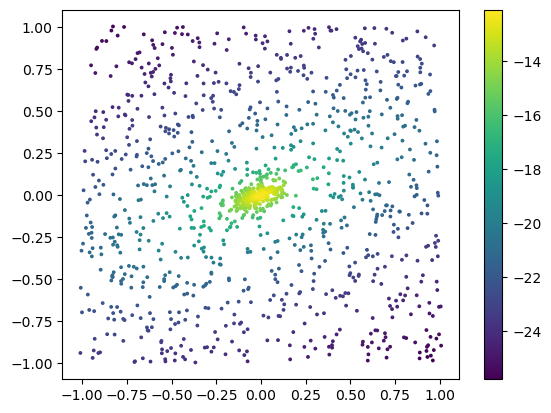

In [ ]:
pos = np.array(
    [
        3600 * RetIIPM_gr_cut["dAlpha"],
        3600 * RetIIPM_gr_cut["dDelta"],
    ]
).T

cov = np.array(
    [
        [RetIIPM_gr_cut["c_xx"], RetIIPM_gr_cut["c_xy"]],
        [RetIIPM_gr_cut["c_xy"], RetIIPM_gr_cut["c_yy"]],
    ]
).T


def plummer_logp(pos, cov, x0, y0, a, eps, theta):

    N = pos.shape[0]
    # Shift the positions according to the center (x0, y0).
    new_pos = np.stack([pos[:, 0] - x0, pos[:, 1] - y0]).T

    # Rotate the positions and covariances according to the angle theta.
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    rot_matrix = np.stack(
        [
            [cos_theta, -sin_theta],
            [sin_theta, cos_theta],
        ]
    )
    pos_rotated = np.dot(new_pos, rot_matrix)

    cov_rotated = np.dot(rot_matrix, np.dot(cov, rot_matrix).T).T

    # Calculate the Plummer profile log-likelihood.
    r2 = ((pos_rotated[:, 0] ** 2) + ((pos_rotated[:, 1] ** 2) / (1 - eps) ** 2))/a**2
    r2_err = (cov_rotated[:, 0, 0] + (cov_rotated[:, 1, 1] / (1 - eps) ** 2))/a**2

    r2_eff = r2

    logp = (
        -np.log(np.pi)-2*np.log(a)-np.log(1-eps)-2*np.log1p(r2_eff)
    )

    return logp


plt.figure()
plt.scatter(
    RetIIPM_gr_cut["dAlpha"],
    RetIIPM_gr_cut["dDelta"],
    s=3,
    c=plummer_logp(
        pos,
        cov,
        0,
        0,
        6.3 * 60,
        0.6,
        (90 - 68) * np.pi / 180,
    ),
)
plt.colorbar()
plt.show()

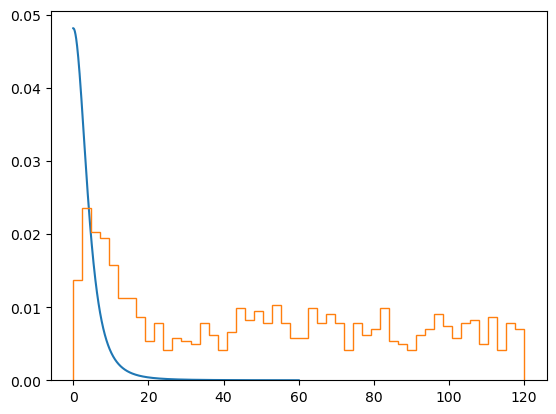

In [ ]:
theta = (90 + 68) * np.pi / 180
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
x, y = np.dot(
    60 * np.array([RetIIPM_gr_cut["dAlpha"], RetIIPM_gr_cut["dDelta"]]).T, rot_matrix
).T
R_real = np.sqrt(x**2 + (y**2 / (1 - 0.6) ** 2))

R = np.linspace(0, 60, 1000)

plt.figure()
plt.plot(R, 6 / (np.pi * 6.3**2) * (1 + R**2 / 6.3**2) ** (-2))
plt.hist(R_real, bins=50, density=True, histtype="step", range=(0, 120))
plt.show()

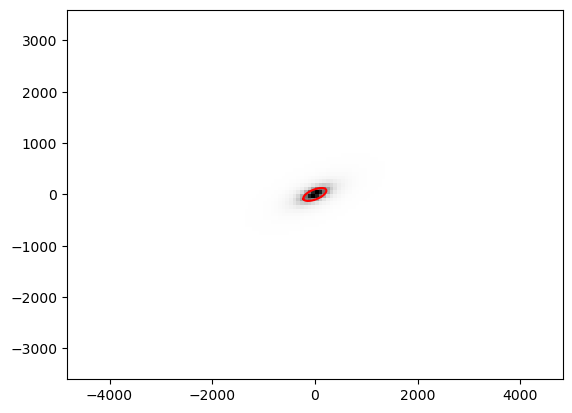

In [ ]:
def plummer_dist(x, y, a, eps, theta):

    rot_matrix = np.array(
        [[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]
    )
    x, y = np.dot(np.array([x, y]).T, rot_matrix).T

    r = np.sqrt(x * x + y * y / (1 - eps) ** 2)

    return 1 / ((np.pi * a * a * (1 - eps)) * (1 + r * r / (a * a)) ** 2)


z = np.linspace(-3600, 3600, 100)
x, y = np.meshgrid(z, z)
z = plummer_dist(x.flatten(), y.flatten(), 6.3 * 60, 0.6, (90 - 68) * np.pi / 180)


plt.figure()
plt.axis("equal")
# plt.scatter(3600*RetIIPM_gr_cut['dAlpha'],3600*RetIIPM_gr_cut['dDelta'],s=3,alpha=0.5)
plt.plot(ra_hlr * 3600, dec_hlr * 3600, c="r")
plt.imshow(
    z.reshape(100, 100), cmap="Greys", origin="lower", extent=[-3600, 3600, -3600, 3600]
)
plt.show()